<a href="https://colab.research.google.com/github/towardsai/ai-tutor-rag-system/blob/main/notebooks/LangGraph_101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LangGraph 101: State Graphs, Checkpointed Memory, Streaming, and Human-in-the-Loop

`create_agent()` gave you an agent in one call — this lesson opens the hood. **LangGraph** is the runtime underneath: applications are **graphs** of plain Python functions that read and update a shared, typed **state**. That one design choice is what buys the production features this course keeps promising: durable per-conversation memory, step-by-step streaming, and the ability to *pause a running agent and ask a human*.

This is the direct prerequisite for Section 13: the production tutor is `create_agent` on LangGraph with an `InMemorySaver` checkpointer keyed by `thread_id` and streamed events. Every one of those words will be code by the end of this notebook.

## 🧭 What You'll Learn

- The three ideas: typed **state**, **nodes** (plain functions), **edges** (including conditional ones)
- Why `add_messages` is a *reducer* — and why state updates are merged, not overwritten
- Building a tool-calling agent as an explicit graph (`ToolNode` + `tools_condition`)
- **Persistence**: `InMemorySaver` + `thread_id` = conversations that remember, per thread
- **Streaming modes**: watching the graph execute node by node
- **Human-in-the-loop**: `interrupt()` to pause before a sensitive action, `Command(resume=…)` to continue

## 1. Setup: Environment, Keys, and Pins

Same stack as the LangChain 101 notebook (pinned as of August 2026); `langgraph` comes along with `langchain` but we pin it explicitly since it is today's subject.

In [1]:
# ============================================================
# ⚙️ Setup — environment, dependencies, API keys, provider
# ============================================================
import os
import sys

IN_COLAB = "google.colab" in sys.modules

# Pick your model provider (dropdown in Colab; edit the values locally)
PROVIDER = "gemini"  # @param ["gemini", "openai", "anthropic"]

# init_chat_model() takes one "provider:model" string — the whole provider
# switch lives in this little table (course-standard models, August 2026):
_MODEL_FOR = {
    "gemini": "google_genai:gemini-3.7-flash",
    "openai": "openai:gpt-5.6-luna",
    "anthropic": "anthropic:claude-sonnet-5",
}
MODEL = _MODEL_FOR[PROVIDER]

_KEY_FOR = {"gemini": "GOOGLE_API_KEY", "openai": "OPENAI_API_KEY", "anthropic": "ANTHROPIC_API_KEY"}
REQUIRED_KEYS = [_KEY_FOR[PROVIDER]]

if IN_COLAB:
    import importlib
    import site
    import subprocess

    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q", "-U",
            "tai-aitutor==0.0.3",
            "langchain==1.3.14",
            "langgraph==1.2.10",
            "langchain-google-genai==4.3.2",
            "langchain-openai==1.4.1",
            "langchain-anthropic==1.5.4",
        ],
        check=True,
    )
    importlib.reload(site)  # make newly installed packages importable without a runtime restart

if not IN_COLAB:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
    # Locally: pip install the same pinned packages once; keys live in a .env file.

from tai_aitutor import setup_notebook

# The standard course key loader — Colab Secrets or a local .env, same code path.
setup_notebook(required_keys=REQUIRED_KEYS)

print(f"✅ Setup complete — {'Colab' if IN_COLAB else 'local'} | model: {MODEL}")

✅ Setup complete — local | model: google_genai:gemini-3.7-flash


In [2]:
from langchain.chat_models import init_chat_model

model = init_chat_model(MODEL)
print(model.invoke("Reply with exactly: ready").text)

ready


## 2. The Three Ideas: State, Nodes, Edges

- **State** is a typed dict every part of the app shares. Each key can have a *reducer* — a rule for how updates combine. `add_messages` is the reducer you will use constantly: node returns get **appended** to the conversation instead of replacing it.
- A **node** is a plain function: state in → *partial* state update out.
- **Edges** say what runs next; **conditional edges** branch on the state.

That's the whole mental model. Here is the smallest possible graph — one model-calling node:

In [3]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    # add_messages is the REDUCER: returned messages are appended, not overwritten
    messages: Annotated[list, add_messages]


def chatbot(state: State):
    """A node is a plain function: read state, return a partial update."""
    return {"messages": [model.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("chatbot", chatbot)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()

result = graph.invoke({"messages": [{"role": "user", "content": "In one sentence: what is LangGraph?"}]})
print(result["messages"][-1].text)

**LangGraph** is a framework for building robust, stateful, and cyclical multi-agent AI workflows modeled as graphs.


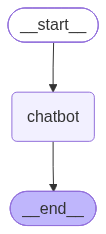

In [4]:
# Every compiled graph can draw itself — useful sanity check as graphs grow.
from IPython.display import Image as IPythonImage, display

try:
    display(IPythonImage(graph.get_graph().draw_mermaid_png()))
except Exception as error:  # rendering needs network access; the graph itself is fine
    print("(diagram rendering unavailable here:", error, ")")
    print(graph.get_graph().draw_ascii())

**What just happened?** `invoke()` seeded the state with one human message; the `chatbot` node returned a one-message update; `add_messages` appended it. The final state is the whole conversation. No magic — you could have written this one function call yourself, and that is precisely the point: LangGraph's value shows up in what comes *next*, not in this cell.

## 3. An Agent, as an Explicit Graph

Now the agents-lesson loop as a graph. Two nodes — the model, and a `ToolNode` that executes tool calls — plus one **conditional edge**: if the model's last message requests tools, go run them; otherwise finish. This is exactly the graph `create_agent()` compiles for you.

In [5]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition


@tool
def course_glossary(term: str) -> str:
    """Look up a term from the RAG course glossary and return its short definition."""
    glossary = {
        "rag": "Retrieval-Augmented Generation: retrieve relevant chunks, then generate an answer grounded in them.",
        "chunking": "Splitting documents into retrieval-sized pieces before embedding.",
        "reranking": "Re-scoring an initial retrieval set with a stronger model to push the best chunks to the top.",
        "hybrid search": "Fusing dense (embedding) and sparse (BM25) retrieval, typically with reciprocal rank fusion.",
        "checkpointer": "LangGraph's persistence layer: saves graph state after each step, keyed by thread_id.",
    }
    return glossary.get(term.strip().lower(), f"'{term}' is not in the course glossary.")


model_with_tools = model.bind_tools([course_glossary])


def agent_node(state: State):
    return {"messages": [model_with_tools.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("agent", agent_node)
builder.add_node("tools", ToolNode([course_glossary]))

builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)  # tool calls → "tools"; none → END
builder.add_edge("tools", "agent")  # after running tools, let the model read the results

agent_graph = builder.compile()

result = agent_graph.invoke(
    {"messages": [{"role": "user", "content": "Use the glossary: what is hybrid search?"}]}
)
for message in result["messages"]:
    kind = type(message).__name__
    if getattr(message, "tool_calls", None):  # the AI turn that requests a tool
        call = message.tool_calls[0]
        print(f"[{kind}] tool call \u2192 {call['name']}({call['args']})")
    else:
        print(f"[{kind}] {message.text}")

[HumanMessage] Use the glossary: what is hybrid search?
[AIMessage] tool call → course_glossary({'term': 'hybrid search'})
[ToolMessage] Fusing dense (embedding) and sparse (BM25) retrieval, typically with reciprocal rank fusion.
[AIMessage] According to the glossary, **hybrid search** is:

> Fusing dense (embedding) and sparse (BM25) retrieval, typically using reciprocal rank fusion.


**What just happened?** The trace is the familiar one — AI message with `tool_calls`, a ToolMessage observation, a grounded answer — but now the loop is *drawn on a map*: `agent → tools → agent → END`. `tools_condition` is just a function reading the last message; you could write your own condition for routing, guardrails, or retries. 📎 *This is the routing lesson's idea (decide, then branch) promoted from an `if` statement to graph topology.*

## 4. Persistence: Memory per `thread_id`

So far every `invoke()` starts from nothing — like the stateless message-list demo in the memory lesson. LangGraph fixes this at the *runtime* level: compile with a **checkpointer** and every step's state is saved under a `thread_id`. Same thread → the conversation continues; new thread → clean slate. This is literally the production tutor's memory mechanism.

In [6]:
from langgraph.checkpoint.memory import InMemorySaver

memory_graph = builder.compile(checkpointer=InMemorySaver())

thread_1 = {"configurable": {"thread_id": "student-alice"}}

print(memory_graph.invoke(
    {"messages": [{"role": "user", "content": "Use the glossary to explain reranking."}]},
    thread_1,
)["messages"][-1].text)

According to the course glossary, **reranking** is the process of:

> **Re-scoring an initial retrieval set with a stronger model to push the best chunks to the top.**

---

### Key Concepts:
1. **Initial Retrieval (Fast & Broad):** A fast, lightweight retrieval method (like vector search or keyword/BM25 search) retrieves a candidate set of documents/chunks.
2. **Re-scoring (Accurate & Deep):** A more computationally intensive, powerful model (such as a cross-encoder) evaluates the query alongside each retrieved chunk in detail.
3. **Optimized Context:** The most relevant chunks are moved to the top of the context window, improving the final response quality generated by the LLM.


In [7]:
# Follow-up with a pronoun — resolvable ONLY if the thread remembers:
print(memory_graph.invoke(
    {"messages": [{"role": "user", "content": "Why does it improve answer quality?"}]},
    thread_1,
)["messages"][-1].text)

Reranking improves answer quality in several key ways:

### 1. **Deeper Semantic Understanding (Joint Attention)**
* **First-stage retrieval (Bi-encoders/Vector Search):** Encodes the query and documents separately into static vector embeddings. While fast, this loses fine-grained, token-level interactions.
* **Rerankers (Cross-encoders):** Process the query and document text **together** across all attention layers. This allows the model to capture nuanced relationships, exact constraints, negations, and complex phrasing that simple similarity search often misses.

---

### 2. **Overcoming "Lost in the Middle"**
* Large Language Models (LLMs) tend to pay the most attention to information placed at the very beginning and end of the context prompt.
* By pushing the most accurate and critical chunks directly to the top, reranking ensures the LLM focuses on the right evidence rather than getting distracted by irrelevant or weakly related text in the middle.

---

### 3. **Noise Reduction 

In [8]:
# A different thread_id shares the graph but none of the memory:
thread_2 = {"configurable": {"thread_id": "student-bob"}}

print(memory_graph.invoke(
    {"messages": [{"role": "user", "content": "Why does it improve answer quality?"}]},
    thread_2,
)["messages"][-1].text)

In the context of **Retrieval-Augmented Generation (RAG)** and AI systems, "it" usually refers to either **RAG itself** or specific enhancement techniques like **Reranking**, **Query Rewriting / HyDE**, or **Chunking**.

Here is why key RAG techniques improve answer quality:

---

### 1. Retrieval-Augmented Generation (RAG) in General
RAG improves answer quality compared to standard Large Language Model (LLM) generation because:
* **Grounding in Real-Time / Domain-Specific Data:** It supplies the model with external, authoritative context from your knowledge base, preventing outdated or missing domain knowledge.
* **Reduction of Hallucinations:** By instructing the model to generate answers based directly on retrieved source documents, the likelihood of making up plausible-sounding false information is significantly reduced.
* **Verifiability & Attribution:** The system can cite specific passages and sources, allowing users to verify facts.

---

### 2. Specific Techniques that Boost Q

**What just happened?** Thread `student-alice` resolved "it" to reranking because the checkpointer replayed her saved state; `student-bob`'s thread had no idea what "it" was. Note what you did *not* write: no history list, no resend logic — 📎 the machinery you built by hand in the memory lesson is now a `compile()` argument. Two honest caveats that matter in production (and are called out in Section 13): `InMemorySaver` lives in-process — restart the process and memory is gone (real deployments use a database-backed checkpointer) — and saved state *grows*; long threads still need the compaction strategies from the memory lesson.

## 5. Streaming: Watching the Graph Run

`invoke()` hides the intermediate steps; `stream()` hands them to you as they happen — per-node updates (`"updates"`), full state snapshots (`"values"`), or token-by-token model output (`"messages"`).

In [9]:
for event in memory_graph.stream(
    {"messages": [{"role": "user", "content": "And what does the glossary say about checkpointer?"}]},
    thread_1,
    stream_mode="updates",
):
    for node_name, update in event.items():
        latest = update["messages"][-1]
        detail = (
            f"tool call \u2192 {latest.tool_calls[0]['name']}"
            if getattr(latest, "tool_calls", None)
            else latest.text[:110]
        )
        print(f"[{node_name}] {type(latest).__name__}: {detail}")

[agent] AIMessage: tool call → course_glossary
[tools] ToolMessage: LangGraph's persistence layer: saves graph state after each step, keyed by thread_id.


[agent] AIMessage: According to the course glossary, a **checkpointer** is:

> **LangGraph's persistence layer: saves graph state


**What just happened?** One event per node: the agent's tool request, the tool's observation, the final answer — live. This is the shape a product UI consumes ("Searching the knowledge base…" indicators are exactly these events), and 📎 the API lesson's SSE endpoint is how they reach a browser. The production tutor streams its agent's events end-to-end this way.

## 6. Human-in-the-Loop: `interrupt()`

Some tool calls should not run unsupervised. Because a checkpointer saves state *between steps*, LangGraph can **pause a live run**, surface what the agent wants to do, and resume — minutes or days later — with a human's verdict. The pause is `interrupt(...)`; the resume is `Command(resume=...)`.

In [10]:
from langgraph.types import Command, interrupt


@tool
def send_course_announcement(text: str) -> str:
    """Send an announcement to every student in the course. Irreversible."""
    return f"📣 Announcement sent to all students: {text!r}"


review_model = model.bind_tools([send_course_announcement])


def drafting_agent(state: State):
    return {"messages": [review_model.invoke(state["messages"])]}


def human_review(state: State):
    """Pause the graph and put the pending tool call in front of a human."""
    tool_call = state["messages"][-1].tool_calls[0]
    decision = interrupt(
        {"pending_action": tool_call["name"], "arguments": tool_call["args"], "reply": "yes / no"}
    )
    if decision == "yes":
        return Command(goto="tools")
    return Command(
        goto=END,
        update={"messages": [{"role": "assistant", "content": "(Action cancelled by the human reviewer.)"}]},
    )


builder = StateGraph(State)
builder.add_node("agent", drafting_agent)
builder.add_node("review", human_review)
builder.add_node("tools", ToolNode([send_course_announcement]))

builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition, {"tools": "review", END: END})
builder.add_edge("tools", "agent")

hitl_graph = builder.compile(checkpointer=InMemorySaver())

thread = {"configurable": {"thread_id": "announcement-1"}}
# The *graph* is the approval gate. Without this instruction a safety-conscious
# model answers "shall I send it?" in prose, never emits the tool call, and the
# review node never runs.
system_rule = (
    "You are a course assistant. When asked to announce something, call "
    "send_course_announcement directly with the announcement text. Never ask the "
    "user to confirm first \u2014 a human reviewer approves every call before it runs."
)

paused = hitl_graph.invoke(
    {
        "messages": [
            {"role": "system", "content": system_rule},
            {"role": "user", "content": "Announce that office hours move to Thursday 5pm."},
        ]
    },
    thread,
)

print("Graph paused. The human sees:")
print(paused["__interrupt__"][0].value)

Graph paused. The human sees:
{'pending_action': 'send_course_announcement', 'arguments': {'text': 'Office hours have moved to Thursday at 5:00 PM.'}, 'reply': 'yes / no'}


In [11]:
# The human approves — resume the SAME thread with their decision:
resumed = hitl_graph.invoke(Command(resume="yes"), thread)
print(resumed["messages"][-1].text)

The announcement that office hours have moved to Thursday at 5:00 PM has been sent to all students.


**What just happened?** The run *stopped inside* the `review` node — `interrupt()` saved everything to the checkpointer and returned control to you with the pending action attached (`__interrupt__`). `Command(resume="yes")` dropped the human's answer back into that exact spot, and the graph carried on to the tool. Try resuming with `"no"` on a fresh thread: the cancel branch answers without ever running the tool. This pattern — approval gates on irreversible actions — is the difference between an agent you demo and an agent you deploy.

## 🧪 Your Turn

- Rerun Section 4's follow-up on `thread_2` after asking Bob a first question — then inspect `memory_graph.get_state(thread_2)`.
- Add a second tool to the agent graph and watch `tools_condition` route between them.
- Change `stream_mode` to `"values"` and diff what you receive per event.
- Make the reviewer reject the announcement (`Command(resume="no")`) and read the resulting trace.
- Sketch the tutor: which nodes would a RAG agent need? (Peek: Section 13's answer is `create_agent` + a retrieval tool + a KB-browsing tool.)

## 🔑 Key Takeaways

- **LangGraph = typed state + plain-function nodes + edges.** `add_messages` is a reducer: updates append; nothing is overwritten by accident.
- The agent loop is a **three-edge graph**: `agent → (tools_condition) → tools → agent`. `create_agent()` compiles exactly this — now you can read it, extend it, and debug it.
- **Persistence is a compile-time argument**: `compile(checkpointer=InMemorySaver())` + a `thread_id` per conversation. In-process memory is for teaching; production swaps in a durable checkpointer — the *interface* stays put.
- **Streaming is built in**: `"updates"` per node, `"values"` for snapshots, `"messages"` for tokens — the events a real UI renders.
- **`interrupt()` / `Command(resume=…)`** turn "agent safety" from a hope into topology: sensitive actions wait for a human, across process time, because state lives in the checkpointer.
- ⏭️ *Section 13 is this notebook at production scale: the tutor's `create_agent` on LangGraph, two grounding tools, per-thread checkpoints, and streamed events through a FastAPI backend.*